# **Importing necessary libraries and loading the data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
df=pd.read_csv(r'monkeypox_covid_dataset.csv')
df.head()

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact,Monkeypox
0,0,0,1,41,0,0,0,39.169328,1,0,0,0
1,1,0,1,57,1,0,0,37.352679,1,0,1,1
2,0,0,0,38,0,1,0,38.942431,1,1,1,0
3,0,0,0,46,0,0,1,38.232668,0,1,0,0
4,0,0,0,68,1,0,0,35.143223,0,0,0,1


# **Exploratory Data Analysis [EDA]**

In [3]:
#Let's print the first 5 records of the data set
df.head()

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact,Monkeypox
0,0,0,1,41,0,0,0,39.169328,1,0,0,0
1,1,0,1,57,1,0,0,37.352679,1,0,1,1
2,0,0,0,38,0,1,0,38.942431,1,1,1,0
3,0,0,0,46,0,0,1,38.232668,0,1,0,0
4,0,0,0,68,1,0,0,35.143223,0,0,0,1


In [4]:
#Let's print the last 5 records of the dataset
df.tail()

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact,Monkeypox
11995,1,1,0,23,0,1,1,35.153357,1,1,1,1
11996,1,1,0,26,1,0,0,38.988999,1,0,1,1
11997,0,1,1,59,1,0,0,36.506413,1,1,0,1
11998,0,0,1,25,0,1,1,36.097282,1,0,0,0
11999,0,1,1,49,0,0,1,39.023289,1,0,0,0


In [5]:
#Let's print the column name
df.columns

Index(['COVID_Symptoms', 'COVID_Tests', 'COVID_Vaccination', 'Age',
       'Contact_with_Monkeypox', 'Travel_History', 'Healthcare_Worker',
       'Body_Temperature', 'Hand_Hygiene', 'Mask_Usage', 'Close_Contact',
       'Monkeypox'],
      dtype='object')

In [6]:
# shape of the dataset
df.shape

(12000, 12)

In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11995    False
11996    False
11997    False
11998    False
11999    False
Length: 12000, dtype: bool

In [8]:
#Let's print the total number of duplicated value
df.duplicated().sum()

0

In [9]:
#Let's print the unique values in our dataset
df.nunique()

COVID_Symptoms                2
COVID_Tests                   2
COVID_Vaccination             2
Age                          62
Contact_with_Monkeypox        2
Travel_History                2
Healthcare_Worker             2
Body_Temperature          12000
Hand_Hygiene                  2
Mask_Usage                    2
Close_Contact                 2
Monkeypox                     2
dtype: int64

In [10]:
#Let's print the data types in our data
df.dtypes

COVID_Symptoms              int64
COVID_Tests                 int64
COVID_Vaccination           int64
Age                         int64
Contact_with_Monkeypox      int64
Travel_History              int64
Healthcare_Worker           int64
Body_Temperature          float64
Hand_Hygiene                int64
Mask_Usage                  int64
Close_Contact               int64
Monkeypox                   int64
dtype: object

In [11]:
#descriptive statistics summary
df.describe

<bound method NDFrame.describe of        COVID_Symptoms  COVID_Tests  COVID_Vaccination  Age  \
0                   0            0                  1   41   
1                   1            0                  1   57   
2                   0            0                  0   38   
3                   0            0                  0   46   
4                   0            0                  0   68   
...               ...          ...                ...  ...   
11995               1            1                  0   23   
11996               1            1                  0   26   
11997               0            1                  1   59   
11998               0            0                  1   25   
11999               0            1                  1   49   

       Contact_with_Monkeypox  Travel_History  Healthcare_Worker  \
0                           0               0                  0   
1                           1               0                  0   
2                

In [12]:
#Let's get the overall information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   COVID_Symptoms          12000 non-null  int64  
 1   COVID_Tests             12000 non-null  int64  
 2   COVID_Vaccination       12000 non-null  int64  
 3   Age                     12000 non-null  int64  
 4   Contact_with_Monkeypox  12000 non-null  int64  
 5   Travel_History          12000 non-null  int64  
 6   Healthcare_Worker       12000 non-null  int64  
 7   Body_Temperature        12000 non-null  float64
 8   Hand_Hygiene            12000 non-null  int64  
 9   Mask_Usage              12000 non-null  int64  
 10  Close_Contact           12000 non-null  int64  
 11  Monkeypox               12000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 1.1 MB


In [13]:
#Let's check the total number of null values present in our dataset
df.isnull().sum()

COVID_Symptoms            0
COVID_Tests               0
COVID_Vaccination         0
Age                       0
Contact_with_Monkeypox    0
Travel_History            0
Healthcare_Worker         0
Body_Temperature          0
Hand_Hygiene              0
Mask_Usage                0
Close_Contact             0
Monkeypox                 0
dtype: int64

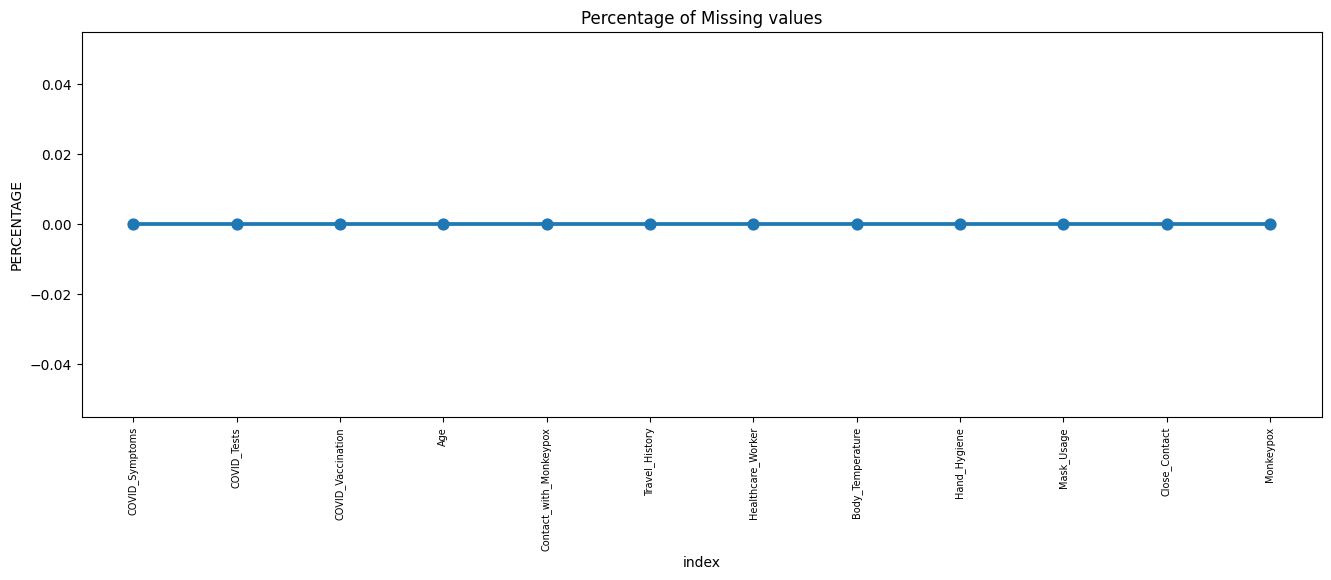

In [14]:
#plot the graph to check wether there are any missing value present
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index',y=0,data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

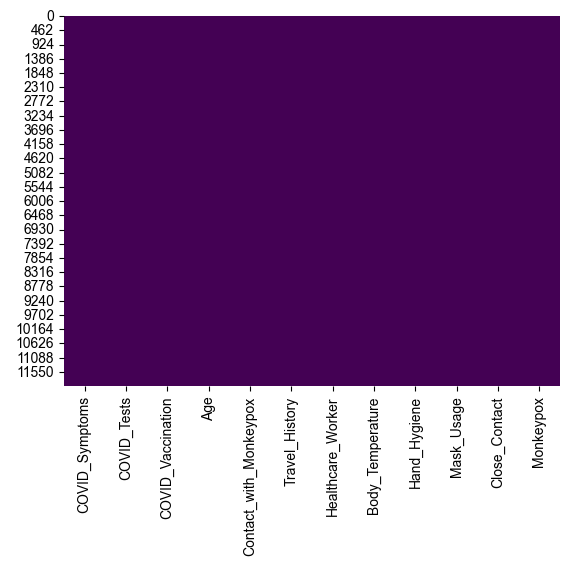

In [15]:
# Create heatmap with missing values in DataFrame highlighted
sns.heatmap(df.isnull(), cbar=False,cmap='viridis')
sns.set(rc={'figure.figsize':(10,5)})

In [16]:
df.isnull().sum().sum()

0

In [17]:
df.head()

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact,Monkeypox
0,0,0,1,41,0,0,0,39.169328,1,0,0,0
1,1,0,1,57,1,0,0,37.352679,1,0,1,1
2,0,0,0,38,0,1,0,38.942431,1,1,1,0
3,0,0,0,46,0,0,1,38.232668,0,1,0,0
4,0,0,0,68,1,0,0,35.143223,0,0,0,1


In [18]:
df["Monkeypox"].value_counts()

Monkeypox
1    7507
0    4493
Name: count, dtype: int64

In [19]:
x=df.drop('Monkeypox',axis=1)
x

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact
0,0,0,1,41,0,0,0,39.169328,1,0,0
1,1,0,1,57,1,0,0,37.352679,1,0,1
2,0,0,0,38,0,1,0,38.942431,1,1,1
3,0,0,0,46,0,0,1,38.232668,0,1,0
4,0,0,0,68,1,0,0,35.143223,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
11995,1,1,0,23,0,1,1,35.153357,1,1,1
11996,1,1,0,26,1,0,0,38.988999,1,0,1
11997,0,1,1,59,1,0,0,36.506413,1,1,0
11998,0,0,1,25,0,1,1,36.097282,1,0,0


In [20]:
y=df['Monkeypox']
y

0        0
1        1
2        0
3        0
4        1
        ..
11995    1
11996    1
11997    1
11998    0
11999    0
Name: Monkeypox, Length: 12000, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)

In [22]:
x_train

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact
831,0,1,1,67,1,1,0,38.124570,0,0,0
6956,1,0,0,51,1,1,0,39.374486,0,1,1
3641,0,1,1,34,0,1,1,38.308137,1,0,1
11559,0,0,0,42,0,1,1,37.077836,0,0,0
11224,1,0,0,26,0,1,0,38.300853,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
599,1,1,0,67,1,0,1,39.668251,1,1,1
5695,0,1,0,28,0,1,1,38.457045,1,1,0
8006,1,1,1,44,0,0,0,36.303993,0,1,1
1361,1,0,0,50,0,1,1,35.395206,0,0,1


In [23]:
y_train

831      1
6956     1
3641     0
11559    0
11224    0
        ..
599      1
5695     0
8006     1
1361     0
1547     0
Name: Monkeypox, Length: 9600, dtype: int64

In [24]:
x_test

,COVID_Symptoms,COVID_Tests,COVID_Vaccination,Age,Contact_with_Monkeypox,Travel_History,Healthcare_Worker,Body_Temperature,Hand_Hygiene,Mask_Usage,Close_Contact
11626,0,1,0,69,0,1,0,38.513189,0,0,1
7377,1,0,1,46,1,1,1,38.622338,1,0,1
6280,1,1,1,28,1,0,0,37.935512,1,0,0
6798,1,1,1,73,1,1,0,35.557750,0,0,0
7259,1,1,0,25,1,1,0,38.836601,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1214,1,1,0,34,1,0,0,38.652109,0,0,0
190,0,1,0,58,1,1,0,37.216468,0,0,1
5861,1,0,0,55,1,1,1,38.740510,1,0,1
11057,0,1,0,66,0,0,0,39.559417,0,0,0


In [25]:
y_test

11626    0
7377     1
6280     1
6798     1
7259     1
        ..
1214     1
190      1
5861     1
11057    0
4831     1
Name: Monkeypox, Length: 2400, dtype: int64

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)
y_pred = lda.predict(x_test)
acc_lda = accuracy_score(y_test, y_pred)
# Calculate precision, recall, and F1-score
precision_lda = precision_score(y_test, y_pred)
recall_lda = recall_score(y_test, y_pred)
f1_score_lda = f1_score(y_test, y_pred)
# Print precision, recall, and F1-score
print("Accuracy:", acc_lda)
print("Precision:", precision_lda)
print("Recall:", recall_lda)
print("F1 Score:", f1_score_lda)
# Generate and print the classification report
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)


Accuracy: 0.9395833333333333
Precision: 1.0
Recall: 0.9027498323272971
F1 Score: 0.9488896721889319
Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.93       909
           1       1.00      0.90      0.95      1491

    accuracy                           0.94      2400
   macro avg       0.93      0.95      0.94      2400
weighted avg       0.95      0.94      0.94      2400



In [32]:
from sklearn.ensemble import AdaBoostClassifier
adb = AdaBoostClassifier()
adb.fit(x_train, y_train)
y_pred = adb.predict(x_test)
acc_adb = accuracy_score(y_test, y_pred)
# Calculate precision, recall, and F1-score
precision_adb = precision_score(y_test, y_pred)
recall_adb = recall_score(y_test, y_pred)
f1_score_adb = f1_score(y_test, y_pred)
# Print precision, recall, and F1-score
print("Accuracy:", acc_adb)
print("Precision:", precision_adb)
print("Recall:", recall_adb)
print("F1 Score:", f1_score_adb)
# Generate and print the classification report
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       909
           1       1.00      1.00      1.00      1491

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [33]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier()
mlp.fit(x_train, y_train)
y_pred = mlp.predict(x_test)
acc_mlp = accuracy_score(y_test, y_pred)
# Calculate precision, recall, and F1-score
precision_mlp = precision_score(y_test, y_pred)
recall_mlp = recall_score(y_test, y_pred)
f1_score_mlp = f1_score(y_test, y_pred)
# Print precision, recall, and F1-score
print("Accuracy:", acc_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1 Score:", f1_score_mlp)
# Generate and print the classification report
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       909
           1       1.00      1.00      1.00      1491

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [34]:
abc=[0,	1	,1,	67,	1,	1,	0	,38.124570,	0,	0,	0]
result=adb.predict([abc])
result=result[0]
if result==0:
    print("The Person not affected with MONKEY_POX")
else:
    print("The Person  affected with MONKEY_POX")

The Person  affected with MONKEY_POX


C:\Users\0591\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


In [35]:
abc=[0,	1,	1,	34,	0,	1	,1,	38.308137,	1	,0,	1]
result=adb.predict([abc])
result=result[0]
if result==0:
    print("The Person not affected with MONKEY_POX")
else:
    print("The Person  affected with MONKEY_POX")

The Person not affected with MONKEY_POX


C:\Users\0591\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
